#Setup

###Imports


In [9]:
import os
import requests
import time
import math
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from config import Config
from RNN import RNNModel, RNN

config = Config()

###Connect to GPU

In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

Using: cpu


### Connect to drive and define paths

In [101]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

drive_dir = "/content/drive/MyDrive/KP_MODEL"
os.makedirs(drive_dir, exist_ok=True)

checkpoint_path_rnn= os.path.join(drive_dir, "shakespeare_rnn.pth")
checkpoint_path_lstm=os.path.join(drive_dir, "shakespeare_lstm.pth")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#Load the Text & Build Vocabulary

In [3]:
data_path = "/Users/laibaqureshi/Desktop/Text Generation/Text-Generation/shakespeare_2.txt"
rnn_trainer = RNN(data_path)

text = rnn_trainer.load()

Text characters length: 1115394


###Analyze the dataset

In [4]:
# Take a look at the first 300 characters in text.
print(text[:300])

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us


###Character vocabulary

In [5]:
vocab_size, chars = rnn_trainer.build_vocab(text)

Vocab size (unique chars): 65
['\n', ' ', '!', '$', '&', "'", ',', '-', '.', '3', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']


###Vectorize the text

In [6]:
char2idx = rnn_trainer.vectorise_text(chars)

{
  '\n':   0,
  ' ' :   1,
  '!' :   2,
  '$' :   3,
  '&' :   4,
  "'" :   5,
  ',' :   6,
  '-' :   7,
  '.' :   8,
  '3' :   9,
  ':' :  10,
  ';' :  11,
  '?' :  12,
  'A' :  13,
  'B' :  14,
  'C' :  15,
  'D' :  16,
  'E' :  17,
  'F' :  18,
  'G' :  19,
  ...
}


In [7]:
idx2char = rnn_trainer.devectorise_text(char2idx)

{0: '\n', 1: ' ', 2: '!', 3: '$', 4: '&', 5: "'", 6: ',', 7: '-', 8: '.', 9: '3', 10: ':', 11: ';', 12: '?', 13: 'A', 14: 'B', 15: 'C', 16: 'D', 17: 'E', 18: 'F', 19: 'G', 20: 'H', 21: 'I', 22: 'J', 23: 'K', 24: 'L', 25: 'M', 26: 'N', 27: 'O', 28: 'P', 29: 'Q', 30: 'R', 31: 'S', 32: 'T', 33: 'U', 34: 'V', 35: 'W', 36: 'X', 37: 'Y', 38: 'Z', 39: 'a', 40: 'b', 41: 'c', 42: 'd', 43: 'e', 44: 'f', 45: 'g', 46: 'h', 47: 'i', 48: 'j', 49: 'k', 50: 'l', 51: 'm', 52: 'n', 53: 'o', 54: 'p', 55: 'q', 56: 'r', 57: 's', 58: 't', 59: 'u', 60: 'v', 61: 'w', 62: 'x', 63: 'y', 64: 'z'}


###Encode the Full Text

In [8]:
encoded = rnn_trainer.encode_text(text, char2idx)

Encoded shape: torch.Size([1115394])
Original vs Encoded text:
Original text: First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you
Vectorised/Encoded text: tensor([18, 47, 56, 57, 58,  1, 15, 47, 58, 47, 64, 43, 52, 10,  0, 14, 43, 44,
        53, 56, 43,  1, 61, 43,  1, 54, 56, 53, 41, 43, 43, 42,  1, 39, 52, 63,
         1, 44, 59, 56, 58, 46, 43, 56,  6,  1, 46, 43, 39, 56,  1, 51, 43,  1,
        57, 54, 43, 39, 49,  8,  0,  0, 13, 50, 50, 10,  0, 31, 54, 43, 39, 49,
         6,  1, 57, 54, 43, 39, 49,  8,  0,  0, 18, 47, 56, 57, 58,  1, 15, 47,
        58, 47, 64, 43, 52, 10,  0, 37, 53, 59,  1, 39, 56, 43,  1, 39, 50, 50,
         1, 56, 43, 57, 53, 50, 60, 43, 42,  1, 56, 39, 58, 46, 43, 56,  1, 58,
        53,  1, 42, 47, 43,  1, 58, 46, 39, 52,  1, 58, 53,  1, 44, 39, 51, 47,
        57, 46, 12,  0,  0, 13, 50, 50, 10,  0, 30, 43, 

###Define Constants

In [10]:
# The maximum length sentence we want for a single input in characters.
batch_size = config.batch_size

examples_per_epoch = len(text) // (config.sequence_length + 1)

print('examples_per_epoch:', examples_per_epoch)

examples_per_epoch: 11043


#Create Dataset

### Split data into training and test sets 85/15

In [11]:
split = int(config.train_split * len(encoded))

train_data = encoded[:split]
test_data  = encoded[split:]


###Dataset class

In [12]:
class CharDataset(Dataset):
    def __init__(self, data, seq_len):
        self.data = data
        self.seq_len = seq_len

    def __len__(self):
        return len(self.data) - self.seq_len

    def __getitem__(self, idx):
        x = self.data[idx : idx + self.seq_len]
        y = self.data[idx + 1 : idx + self.seq_len + 1]
        return x, y

###DataLoader

In [13]:
dataset = CharDataset(train_data, config.sequence_length)
data_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)

In [14]:
# For each sequence, duplicate and shift it to form the input and target text
xb, yb = next(iter(data_loader))
print("Batch input shape:", xb.shape)
print("Batch target shape:", yb.shape)

Batch input shape: torch.Size([64, 100])
Batch target shape: torch.Size([64, 100])


In [115]:
# Decode a few sequences to inspect them
num_examples_to_show = 3

for i in range(num_examples_to_show):
    inp = ''.join(idx2char[idx.item()] for idx in xb[i])
    tgt = ''.join(idx2char[idx.item()] for idx in yb[i])

    print(f"\nExample {i+1}:")
    print("Input sequence:")
    print(repr(inp[:100]))   # print first 120 chars only

    print("\nTarget sequence:")
    print(repr(tgt[:100]))


Example 1:
Input sequence:
"s of heaven; on whom it will, it will;\nOn whom it will not, so; yet still 'tis just.\n\nLUCIO:\nWhy, ho"

Target sequence:
" of heaven; on whom it will, it will;\nOn whom it will not, so; yet still 'tis just.\n\nLUCIO:\nWhy, how"

Example 2:
Input sequence:
"t to be shown,\nBut to rejoice in splendor of mine own.\n\nLADY CAPULET:\nNurse, where's my daughter? ca"

Target sequence:
" to be shown,\nBut to rejoice in splendor of mine own.\n\nLADY CAPULET:\nNurse, where's my daughter? cal"

Example 3:
Input sequence:
'd won;\nHis hands were guilty of no kindred blood,\nBut bloody with the enemies of his kin.\nO Richard!'

Target sequence:
' won;\nHis hands were guilty of no kindred blood,\nBut bloody with the enemies of his kin.\nO Richard! '


#RNN

###Training Setup for RNN



In [17]:
rnn_model = RNNModel(vocab_size).to(device)

rnn_loss_fn = nn.CrossEntropyLoss()
rnn_optimizer = torch.optim.Adam(rnn_model.parameters(), lr=0.001)

###Training RNN With Early Stopping

In [118]:
# TRAINING LOOP (TRAIN-LOSS EARLY STOP)
rnn_patience = 4
rnn_epochs   = 100
skip_training = True

# RESUME IF CHECKPOINT EXISTS
if os.path.exists(checkpoint_path_rnn):
    checkpoint = torch.load(checkpoint_path_rnn, map_location=device)

    rnn_model.load_state_dict(checkpoint["model_state"])
    rnn_optimizer.load_state_dict(checkpoint["optimizer_state"])

    rnn_train_losses    = checkpoint["train_losses"]
    best_rnn_train_loss = checkpoint["best_train_loss"]
    rnn_wait            = checkpoint["wait"]
    start_epoch         = checkpoint["epoch"] + 1
    if rnn_wait >= rnn_patience-1:
        print("Early stopping was already triggered previously. Not resuming training.")
        skip_training = True  # <--- STOP TRAINING
    else:
        print("Resuming RNN training from epoch:", start_epoch)
else:
    print("No RNN checkpoint found. Starting fresh.")
    rnn_train_losses    = []
    best_rnn_train_loss = float("inf")
    rnn_wait            = 0
    start_epoch         = 1

if not skip_training:
  for epoch in range(start_epoch, rnn_epochs + 1):
      rnn_model.train()
      total_loss = 0.0
      steps = 0

      for x, y in data_loader:
          x = x.to(device)
          y = y.to(device)

          hidden = rnn_model.init_hidden(x.size(0))  # RNN hidden state

          rnn_optimizer.zero_grad()
          logits, hidden = rnn_model(x, hidden)

          loss = rnn_loss_fn(
              logits.reshape(-1, vocab_size),
              y.reshape(-1)
          )

          loss.backward()
          rnn_optimizer.step()

          total_loss += loss.item()
          steps += 1

      train_loss = total_loss / steps
      rnn_train_losses.append(train_loss)

      print(f"[RNN] Epoch {epoch}/{rnn_epochs} | Train Loss: {train_loss:.4f} | Perplexity: {math.exp(train_loss):.2f}")

      # EARLY STOPPING BASED ON TRAIN LOSS
      if train_loss <= best_rnn_train_loss:
          best_rnn_train_loss = train_loss

          # save full checkpoint to Google Drive
          torch.save({
              "epoch": epoch,
              "model_state": rnn_model.state_dict(),
              "optimizer_state": rnn_optimizer.state_dict(),
              "best_train_loss": best_rnn_train_loss,
              "wait": rnn_wait,
              "train_losses": rnn_train_losses,
          }, checkpoint_path_rnn)

          print("   → Saved RNN checkpoint to Google Drive.")
      else:
          rnn_wait += 1
          print(f"   → No improvement. Patience {rnn_wait}/{rnn_patience}")
          if rnn_wait >= rnn_patience:
              print("RNN early stopping triggered (training loss).")
              break

Early stopping was already triggered previously. Not resuming training.


###PLOT RNN TRAINING LOSS

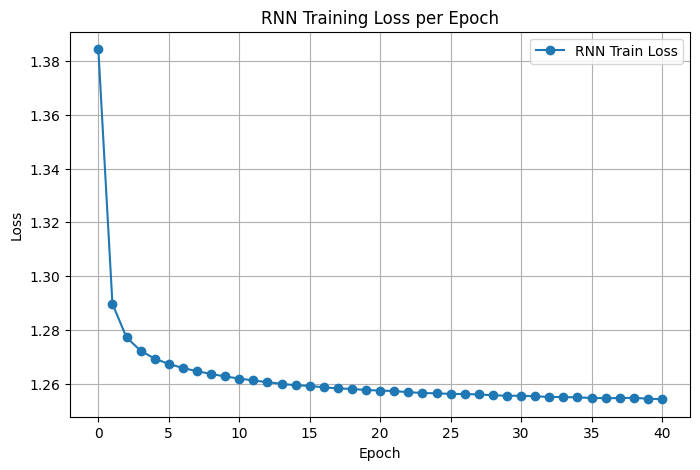

In [119]:
# PLOT RNN TRAINING LOSS
plt.figure(figsize=(8,5))
plt.plot(rnn_train_losses, marker='o', label="RNN Train Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("RNN Training Loss per Epoch")
plt.grid(True)
plt.legend()
plt.show()